# ETF Arbitrage

## Data

Use the data in `data/etf_arb_data.xlsx`
* tab `descriptions`: fund snapshot as of the quote date
* tab `prices`: daily closing price per share
* tab `nav`: daily net asset value (NAV) per share

The premium/discount of price to NAV is

$$\frac{P_t}{\text{NAV}_t} - 1$$

A positive value is a premium; a negative value is a discount.

The file includes SPY (S&P 500 equities), HYG (high-yield corporate bonds), and GBTC (bitcoin). This exercise uses SPY and HYG.

#### Note

The prices are split-adjusted but not dividend-adjusted, so each day's price and NAV are comparable per-share quotes. (See the discussion of ETFs for more on measuring the premium.)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prompt_toolkit.utils import to_int

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14

In [4]:
FILEDATA = '../data/etf_arb_data.xlsx'

info   = pd.read_excel(FILEDATA, sheet_name='descriptions', index_col=0)
prices = pd.read_excel(FILEDATA, sheet_name='prices', index_col=0)
nav    = pd.read_excel(FILEDATA, sheet_name='nav', index_col=0)

fund_info = info.rename(columns={
    'name': 'Name',
    'quoteType': 'Type',
    'currency': 'Currency',
    'volume': 'Volume',
    'totalAssets': 'Total Assets',
    'expense_ratio': 'Expense Ratio',
    'as_of': 'As of',
}).rename_axis('Ticker')

(fund_info.style
 .format({
     'Volume': '{:,.0f}',
     'Total Assets': lambda x: f'${x / 1e9:,.1f}B',
     'Expense Ratio': '{:.2%}',
 })
 .set_properties(
     subset=['Volume', 'Total Assets', 'Expense Ratio'],
     **{'text-align': 'right', 'padding-left': '1.25em'},
 ))

,Name,Type,Currency,Volume,Total Assets,Expense Ratio,As of
Ticker,,,,,,,
SPY,SS SPDR S&P 500 ETF TRUST-US,ETP,USD,"87,683,517",$776.9B,0.09%,2026-06-09
HYG,ISHR IBX USD HIYLD CB ETF-UI,ETP,USD,"34,705,836",$16.1B,0.49%,2026-06-09
GBTC,GRAYSCALE BITCOIN TRUST ETF,ETP,USD,"3,067,475",$8.9B,1.50%,2026-06-09


***

# 1. The SPY Premium

SPY creations and redemptions are done in units of 50,000 shares. (See the discussion of ETFs for the mechanics of creation and redemption.)

### 1.1.

For each fund, calculate the daily premium/discount.

For SPY, report the mean, standard deviation, min, and max, in basis points. Plot the series over time.

How closely does SPY trade to its NAV on a typical day?

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE = "../data/etf_arb_data.xlsx"

prices = pd.read_excel(
    FILE,
    sheet_name="prices",
    index_col="date",
    parse_dates=True
)

nav = pd.read_excel(
    FILE,
    sheet_name="nav",
    index_col="date",
    parse_dates=True
)

In [6]:
# premium pricing calculation for HYG and SPY
premium = prices.div(nav) - 1

premium.head()

,SPY,HYG,GBTC
date,,,
2015-01-02,-0.000141,0.001677,NaN
2015-01-05,0.000020,-0.006158,NaN
2015-01-06,-0.000515,-0.005511,NaN
2015-01-07,0.000005,-0.001123,NaN
2015-01-08,-0.000151,0.001564,NaN


In [7]:
# conversion to basis points for SPY
spy_prem_bps = premium['SPY'].dropna() * 10_000

In [8]:
spy_moments = spy_prem_bps.agg(['mean', 'std', 'min', 'max']).to_frame("SPY Premium n Discount")
spy_moments

,SPY Premium n Discount
mean,0.304842
std,4.225173
min,-79.801390
max,90.041973


In [9]:
# when the extreme disc occurred
print("Deepest discount:")
print(spy_prem_bps.idxmin(), spy_prem_bps.min())


Deepest discount:
2020-03-13 00:00:00 -79.8013897560279


In [10]:
# when the extreme prem occurred
print("\nLargest premium:")
print(spy_prem_bps.idxmax(), spy_prem_bps.max())


Largest premium:
2025-04-09 00:00:00 90.04197348582154


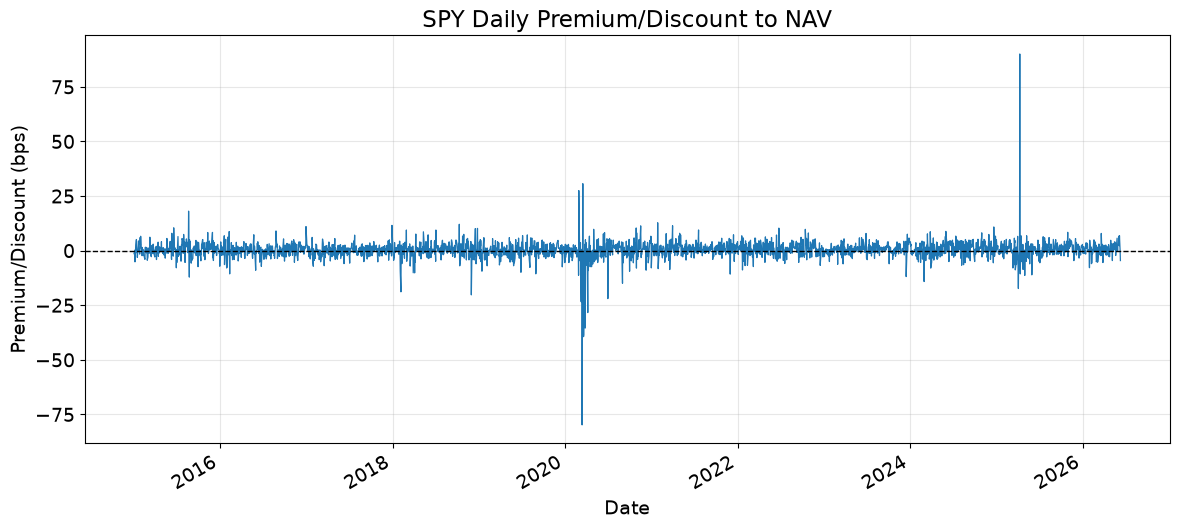

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

spy_prem_bps.plot(
    ax=ax,
    linewidth=0.9,
    title="SPY Daily Premium/Discount to NAV"
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
# restricted vert range to ignore extremities on a typical trading day
ax.set_xlabel("Date")
ax.set_ylabel("Premium/Discount (bps)")
ax.grid(alpha=0.3)

plt.show()

#### How closely does SPY trade to its NAV on a typical day?


- SPY trades very closely to its NAV on a typical day. Its average premium was approximately 0.30 basis points, meaning that there was almost no systematic tendency for SPY to trade above or below NAV.
- The daily volatility/ std dev was approximately 4.23 basis points, which means that ordinary pricing deviations were just a few basis points.
- The minimum and maximum were rare outliers and not representative of normal trading conditions.
- This close relationship between price and NAV might be due to the highly liquid underlying basket and an active/ effective creation-redemption arbitrage mechanism.

### 1.2.

Suppose SPY closes at a 0.50% premium to NAV.

Describe in detail the trade an authorized participant would put on to capture this. Specify each leg: what is bought, what is delivered, and what is sold.

Using the most recent NAV in the data, calculate the gross profit on one creation unit (50,000 shares).

#### AP creation

Since SPY's market price is 0.50% greater than the per-share value of its underlying basket:

$$
P_{SPY}=\text{NAV}\times(1+0.005).
$$

An AP can capture the premium by:

1. **Buying the underlying creation basket.** Purchasing the underlying securities in the quantities and weights needed for one SPY creation unit. This is worth  $50{,}000\times\text{NAV}$.
2. **Delivering the basket to the SPY trust.** Transfering the underlying securities to the fund via the primary-market creation process.
3. **Reception of the 50,000 newly created SPY shares.** In exchange for the basket, the AP receives one creation unit from the fund.
4. **Selling the SPY shares at the premium.** Selling the shares in the secondary market at $\text{NAV}\times1.005$ per share.

To make profit while reducing risk of apparent premium pricing, the AP can short SPY while purchasing the basket,and  then use the newly created shares to cover the short. Thus achieving profit upon successful  creation of the unit.


Without the fees and trading costs, gross profit is:

$$
\text{Gross profit}=50{,}000\times\text{NAV}\times0.005.
$$


In [12]:
spy_nav = nav['SPY'].dropna().sort_index()

latest_date = spy_nav.index[-1]
latest_nav = spy_nav.iloc[-1]

premium_rate = 0.005

premium_market_price = latest_nav * (1 + premium_rate)
basket_purchase_cost = latest_nav * 50_000
spy_sale_proceeds = premium_market_price * 50_000
gross_profit = spy_sale_proceeds - basket_purchase_cost

print("Gross profit:", int(gross_profit))

Gross profit: 184346


### 1.3.

Suppose the authorized participant pays a \$3,000 creation fee per order, plus 3 basis points in trading costs on the basket.

At what premium does the creation trade break even?

Compare this breakeven to your statistics from 1.1. What keeps SPY trading in such a tight band?

#### Breakeven premium

An AP earns the premium on the full creation unit after covering both the fixed creation fee and the proportional basket-trading cost.

Let:

- $N=50{,}000$ SPY shares per creation unit,
- $NAV$ be the most recent SPY NAV per share,
- $F=\$3{,}000$ be the fixed creation fee,
- $c=0.0003$ be the 3-basis-point basket-trading cost,
- $p^*$ be the breakeven premium.

At breakeven:

$$
p^*(N\times NAV)=F+c(N\times NAV).
$$

Thus:

$$
p^*=c+\frac{F}{N\times NAV}.
$$


In [11]:
creation_fee = 3_000
basket_trading_cost_rate = 3 / 10_000  # 3bps

basket_value = latest_nav * 50_000
basket_trading_cost = basket_value * basket_trading_cost_rate
total_creation_cost = creation_fee + basket_trading_cost

breakeven_premium = total_creation_cost / basket_value
breakeven_premium_bps = breakeven_premium * 10_000

print("Breakeven premium:", breakeven_premium_bps)


Breakeven premium: 3.8136855398315346


#### Interpretation

Using the most recent NAV, **$737.3856**, one 50,000-share creation unit has a basket value of:

$$
50{,}000\times\$737.3856=\$36{,}869{,}280.
$$

The 3-basis-point basket-trading cost is:

$$
0.0003\times\$36{,}869{,}280=\$11{,}060.78.
$$

Plus the $3,000 creation fee:

$$
\$11{,}060.78+\$3{,}000=\$14{,}060.78.
$$

The creation trade thus breaks even at:

$$
p^*=\frac{\$14{,}060.78}{\$36{,}869{,}280}
=0.00038137
=0.03814\%
=\boxed{3.81\text{ bps}}.
$$


In [12]:
days_above_breakeven = (spy_prem_bps > breakeven_premium_bps).sum()

print("Days above breakeven:", days_above_breakeven)

Days above breakeven: 312



- 3.81 bps is considerably larger than the historical mean premium of about 0.30 bps, but also quite close to its daily std dev of approximately **4.23 bps**.
- SPY exceeded the estimated 3.81-basis-point creation threshold on **312 of 2,875 observations**, approximately **10.85%** of days as calculated above
- SPY remains in a tight band around NAV because market makers and APs compete to exploit deviations:
    - When SPY trades sufficiently above NAV, they can buy the underlying basket, create new SPY shares, and sell those shares, increasing supply and pushing its price toward NAV.
    - When SPY trades sufficiently below NAV, the reverse redemption trade creates SPY buying pressure and selling pressure in the basket.
    - SPY's highly liquid shares and the liquid S&P 500 basket may end up keep these trading costs low, allowing such small deviations to trigger corrective arbitrage pressure.


# 2. HYG in March 2020

HYG holds high-yield corporate bonds, a much less liquid basket than the S&P 500.

### 2.1.

Plot HYG's premium/discount for 2020. Report the deepest discount and the largest premium of the year, along with their dates.

Deepest discount in 2020: -127.38853503184822 on 2020-03-20 00:00:00
Largest premium in 2020: 458.4126984126979 on 2020-04-09 00:00:00


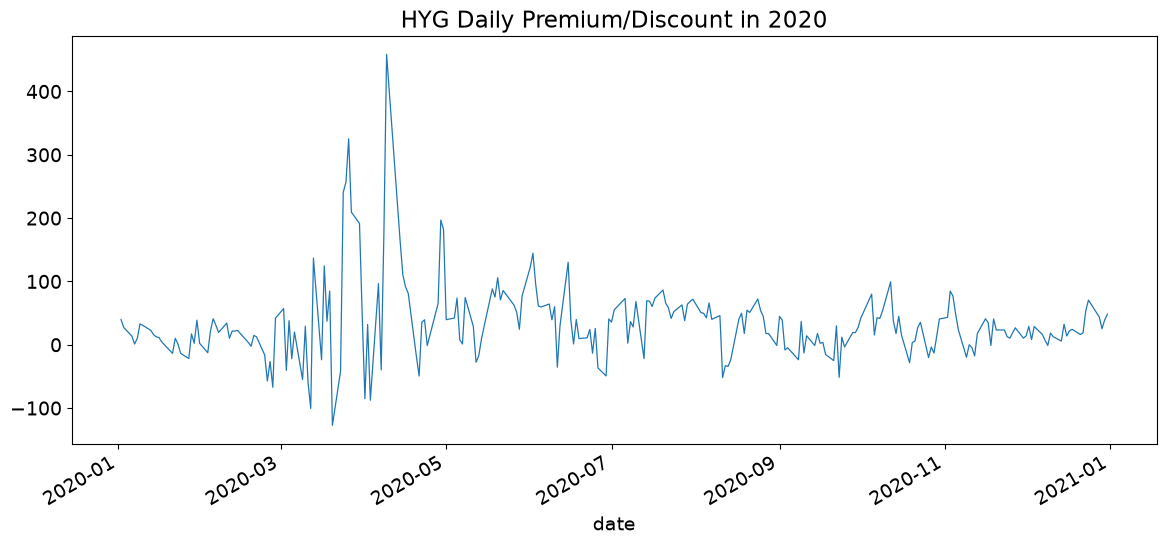

In [23]:
HYG_premium = premium['HYG'].dropna() * 10_000 #In basis points (bps)
HYG_premium_2020 = HYG_premium[HYG_premium.index.year == 2020]

# Plotting HYG premium/discount to NAV in 2020
fig, ax = plt.subplots(figsize=(14, 6))
HYG_premium_2020.plot(
    ax=ax,
    linewidth=0.9,
    title="HYG Daily Premium/Discount in 2020"
)  

# Report deepest discount and largest premiums of the year and the dates
deepest_dsicount = HYG_premium_2020.min()
deepest_discount_date = HYG_premium_2020.idxmin()
largest_premium = HYG_premium_2020.max()
largest_premium_date = HYG_premium_2020.idxmax()

print("Deepest discount in 2020:", deepest_dsicount, "on", deepest_discount_date)
print("Largest premium in 2020:", largest_premium, "on", largest_premium_date)

### 2.2.

Consider the discount of March 2020. The redemption trade would be to buy HYG at the discount, redeem the shares for the bonds, and sell the bonds at their NAV marks.

Is this an arbitrage? Give at least two reasons the discount was not free money.

In [21]:
HYG_discount_2020_march = HYG_premium_2020[(HYG_premium_2020.index.month == 3) & (HYG_premium_2020 < 0)]
print(HYG_discount_2020_march)

date
2020-03-03    -40.560899
2020-03-05    -22.039207
2020-03-09    -54.985337
2020-03-11    -59.026070
2020-03-12   -100.765306
2020-03-16    -23.737307
2020-03-20   -127.388535
2020-03-23    -42.077771
Name: HYG, dtype: float64


Eventhough the arbitrage looks similar to that of SPY, but HYG, as a corporate bond ETF, has very different underlying economics that prevent it from becoming a risk-free, executable trades because:

- Many high-yield bonds traded infrequently, so NAV relied on dealer quotes or stale evaluated prices. During March 2020, the actual bid at which the bonds could be sold was often far below the NAV mark.

- The bonds were extremely costly to liquidate. Selling a large redemption basket could consume or even exceed the apparent discount.

### 2.3.

In those weeks, which was the better measure of the portfolio's value: the ETF price or the NAV?

What does the premium of April 2020 indicate on this question?

<Axes: title={'center': 'HYG Daily Premium/Discount in March and April 2020'}, xlabel='date'>

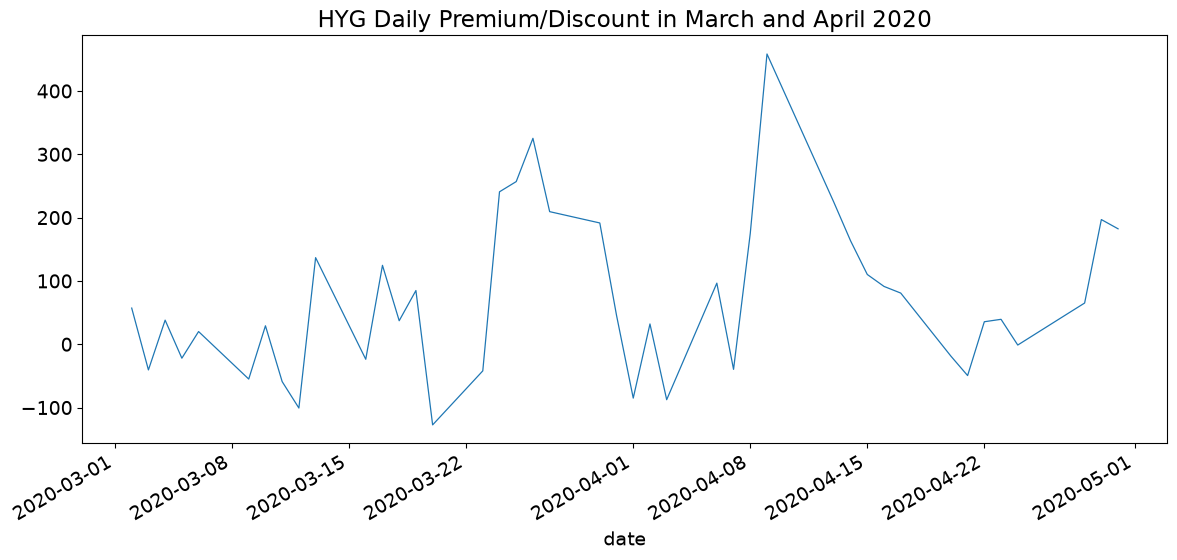

In [22]:
HYG_premium_2020_march_april = HYG_premium_2020[(HYG_premium_2020.index.month == 3) | (HYG_premium_2020.index.month == 4)]

# Plotting HYG premium/discount to NAV in March and April 2020
fig, ax = plt.subplots(figsize=(14, 6))
HYG_premium_2020_march_april.plot(
    ax=ax,
    linewidth=0.9,
    title="HYG Daily Premium/Discount in March and April 2020"
)

**Answer**: During those weeks, the ETF price was probably the better real-time measure of the portfolio’s executable market value. HYG traded continuously, while its NAV depended on estimated prices for bonds that might not even have traded recently.

The shift from a discount in March to a large premium in late-March, early-April supports this chooice. As the credit market recovered,  HYG’s price increased faster than its reported NAV. Thus, the April premium suggests that the NAV understated rather than overstated the bonds’ current value. However, some of the premium may also have reflected unusually strong demand for HYG’s liquidity and anticipated Federal Reserve purchases following the April 9 announcement.